# Conclusions and Visuals
We will now use everthing we learned about this lesson to tackle the fuel economy dataset we cleaned and manipulated from last lesson. Use the space below to address questions on datasets `clean_08.csv` and `clean_18.csv`.
Answer the questions below:
  * Are more unique models using alternative fuels in 2018 compared to 2008? By how much?
  * How much have vehicle classes improved in fuel economy (increased in mpg)?
  * What are the characteristics of SmartWay vehicles? Have they changed over time? (mpg, greenhouse gas)
  * What features are associated with better fuel economy (mpg)?

In [1]:
# inport pandas
import pandas as pd

In [2]:
# load datasets
df_08 = pd.read_csv('clean_08.csv')
df_18 = pd.read_csv('clean_18.csv')

In [3]:
df_08.head(1)

,model,displ,cyl,trans,drive,fuel,veh_class,air_pollution_score,city_mpg,hwy_mpg,cmb_mpg,greenhouse_gas_score,smartway
0,ACURA MDX,3.7,6,Auto-S5,4WD,Gasoline,SUV,7.0,15.0,20.0,17.0,4,no


### Q1: Are more unique models using alternative sources of fuel? By how much?

Let's first look at what the sources of fuel are and which ones are alternative sources.

In [4]:
df_08.fuel.value_counts()

fuel
Gasoline    984
CNG           1
ethanol       1
gas           1
Name: count, dtype: int64

In [5]:
df_18.fuel.value_counts()

fuel
Gasoline       749
Ethanol         26
Gas             26
Diesel          19
Electricity     12
Name: count, dtype: int64

Looks like the alternative sources of fuel available in 2008 are CNG and ethanol, and those in 2018 ethanol and electricity. (You can use Google if you weren't sure which ones are alternative sources of fuel!)

In [12]:
# how many unique models used alternative sources of fuel in 2008
d_alt_08 = df_08.query('fuel == "ethanol" or fuel == "CNG"')
alt_08 = d_alt_08['model'].nunique()
alt_08

2

In [13]:
# how many unique models used alternative sources of fuel in 2018
d_alt_18 = df_18.query('fuel == "Ethanol" or fuel == "Electricity"')
alt_18 = d_alt_18['model'].nunique()
alt_18

26

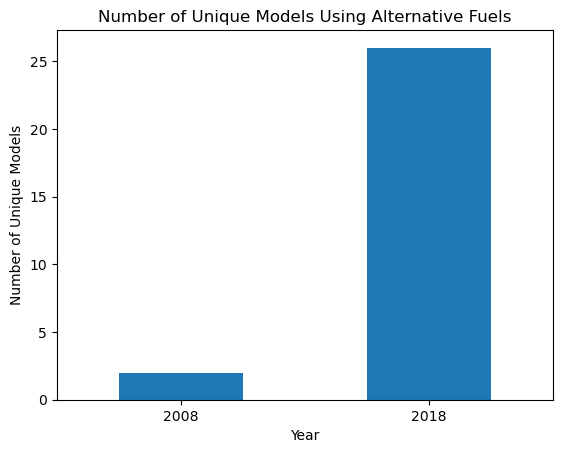

In [14]:
# Create a bar chart with both 2008 and 2018 alternative source numbers
pd.DataFrame(
    {"year": ["2008", "2018"], "model_num": [alt_08, alt_18]}
).plot(
    kind="bar",
    x="year",
    title="Number of Unique Models Using Alternative Fuels",
    legend=False,
    xlabel="Year",
    ylabel="Number of Unique Models",
    rot=0
);

Since 2008, the number of unique models using alternative sources of fuel increased by 24. We can also look at proportions.

In [15]:
# total unique models each year
total_08 = df_08['model'].nunique()
total_18 = df_18['model'].nunique()
total_08, total_18

(377, 357)

In [16]:
# Find the proportion of alternative models by the total number of models for 2008 and 2018
prop_08 = alt_08 / total_08
prop_18 = alt_18 / total_18
prop_08, prop_18

(0.005305039787798408, 0.07282913165266107)

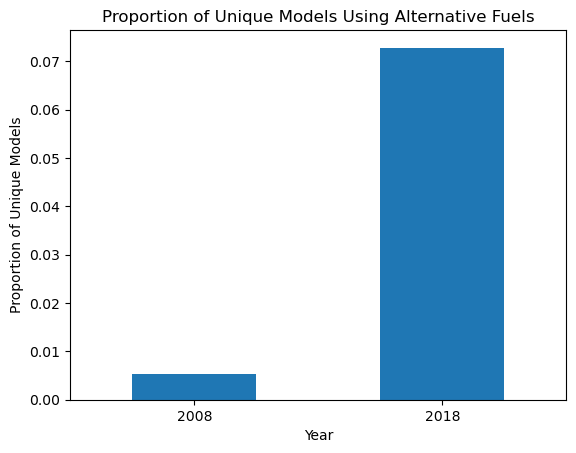

In [17]:
# Create a bar chart with both 2008 and 2018 proportion values
pd.DataFrame(
    {"year": ["2008", "2018"], "model_num": [prop_08, prop_18]}
).plot(
    kind="bar",
    x="year",
    title="Proportion of Unique Models Using Alternative Fuels",
    legend=False,
    xlabel="Year",
    ylabel="Proportion of Unique Models",
    rot=0
);

### Q2: How much have vehicle classes improved in fuel economy?  

Let's look at the average fuel economy for each vehicle class for both years.

In [19]:
# group by veh_class and find the mean of cmb_mpg
veh_08 = df_08.groupby('veh_class')['cmb_mpg'].mean()
veh_08

veh_class
SUV              18.471429
large car        18.509091
midsize car      21.601449
minivan          19.117647
pickup           16.277108
small car        21.105105
station wagon    22.366667
van              14.952381
Name: cmb_mpg, dtype: float64

In [20]:
veh_18 = df_18.groupby('veh_class')['cmb_mpg'].mean()
veh_18

veh_class
large car          23.409091
midsize car        27.884058
minivan            20.800000
pickup             18.589744
small SUV          24.074074
small car          25.421053
special purpose    18.500000
standard SUV       18.197674
station wagon      27.529412
Name: cmb_mpg, dtype: float64

In [21]:
# Find how much they've increased by for each vehicle class
# Take the difference of veh_18 and veh_08 to find the increase
inc = veh_18 - veh_08
inc

veh_class
SUV                     NaN
large car          4.900000
midsize car        6.282609
minivan            1.682353
pickup             2.312635
small SUV               NaN
small car          4.315948
special purpose         NaN
standard SUV            NaN
station wagon      5.162745
van                     NaN
Name: cmb_mpg, dtype: float64

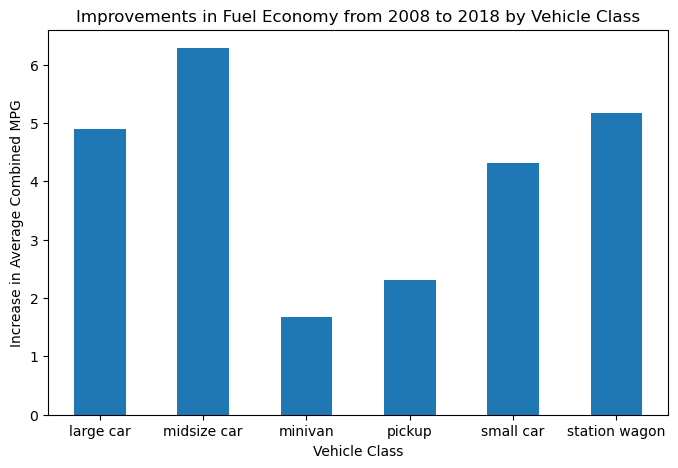

In [22]:
# Drop any NaN values to only plot the classes that exist in both years
inc.dropna(inplace=True)
# Create a bar chart to show the increase for vehicle types 
inc.plot(
    kind="bar",
    x="year",
    title="Improvements in Fuel Economy from 2008 to 2018 by Vehicle Class",
    legend=False,
    xlabel="Vehicle Class",
    ylabel="Increase in Average Combined MPG",
    rot=0,
    figsize=(8, 5)
);

### Q3: What are the characteristics of SmartWay vehicles? Have they changed over time?

We can analyze this by filtering each dataframe by SmartWay classification and exploring these datasets.

In [23]:
# smartway labels for 2008
df_08.smartway.unique()

<StringArray>
['no', 'yes']
Length: 2, dtype: str

In [24]:
# get all smartway vehicles in 2008
smart_08 = df_08.query('smartway == "yes"')

In [25]:
# explore smartway vehicles in 2008
smart_08.describe()

,displ,cyl,air_pollution_score,city_mpg,hwy_mpg,cmb_mpg,greenhouse_gas_score
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000
mean,2.602895,4.826316,7.365789,20.984211,28.413158,23.736842,6.868421
std,0.623436,1.002025,1.148195,3.442672,3.075194,3.060379,0.827338
min,1.300000,4.000000,6.000000,17.000000,22.000000,20.000000,6.000000
25%,2.275000,4.000000,7.000000,19.000000,26.000000,22.000000,6.000000
50%,2.400000,4.000000,7.000000,20.000000,28.000000,23.000000,7.000000
75%,3.000000,6.000000,7.000000,22.000000,30.000000,25.000000,7.000000
max,5.000000,8.000000,9.500000,48.000000,45.000000,46.000000,10.000000


Use what you've learned so for to further explore this dataset on 2008 smartway vehicles.

In [26]:
# smartway labels for 2018
df_18.smartway.unique()

<StringArray>
['No', 'Yes', 'Elite']
Length: 3, dtype: str

In [27]:
# get all smartway vehicles in 2018
smart_18 = df_18.query('smartway == "Yes" or smartway == "Elite"')

In [28]:
smart_18.describe()

,displ,cyl,air_pollution_score,city_mpg,hwy_mpg,cmb_mpg,greenhouse_gas_score
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,1.787963,3.935185,5.212963,34.907407,41.472222,37.361111,7.925926
std,0.408031,0.416329,1.798498,16.431982,13.095236,14.848429,1.197378
min,1.200000,3.000000,3.000000,25.000000,27.000000,26.000000,7.000000
25%,1.500000,4.000000,3.000000,28.000000,36.000000,31.000000,7.000000
50%,1.700000,4.000000,5.500000,28.500000,37.000000,32.000000,7.000000
75%,2.000000,4.000000,7.000000,31.250000,40.250000,35.000000,9.000000
max,3.500000,6.000000,7.000000,113.000000,99.000000,106.000000,10.000000


Use what you've learned so for to further explore this dataset on 2018 smartway vehicles.

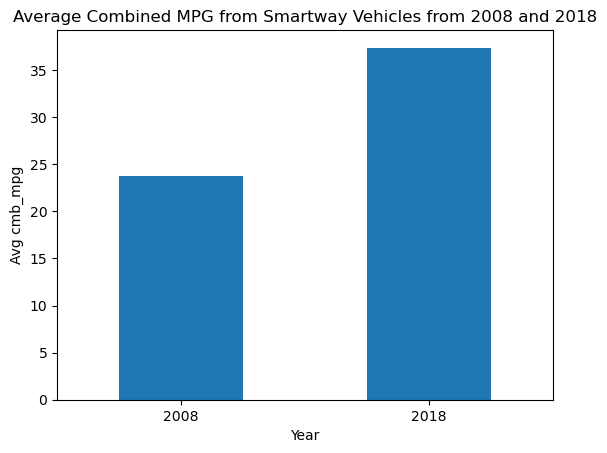

In [29]:
# Create a bar chart to find average cmb_mpg of smartway vehicles
pd.DataFrame(
    {"year": ["2008", "2018"], "model_num": [smart_08["cmb_mpg"].mean(), smart_18["cmb_mpg"].mean()]}
).plot(
    kind="bar",
    x="year",
    title="Average Combined MPG from Smartway Vehicles from 2008 and 2018",
    legend=False,
    xlabel="Year",
    ylabel="Avg cmb_mpg",
    rot=0
);

### Q4: What features are associated with better fuel economy?

You can explore trends between cmb_mpg and the other features in this dataset, or filter this dataset like in the previous question and explore the properties of that dataset. For example, you can select all vehicles that have the top 50% fuel economy ratings like this.

In [33]:
# Create the top 50% by finding cmb_mpg >= the average cmb_mpg
# Create the bottom 50% by finding cmb_mpg < the average cmb_mpg
top_08 = df_08[df_08['cmb_mpg'] >= df_08['cmb_mpg'].mean()]
bottom_08 = df_08[df_08['cmb_mpg'] < df_08['cmb_mpg'].mean()]
top_08.describe()

,displ,cyl,air_pollution_score,city_mpg,hwy_mpg,cmb_mpg,greenhouse_gas_score
count,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000,519.000000
mean,2.667823,4.890173,6.998073,20.317919,27.603083,22.992293,6.639692
std,0.665551,1.034856,1.159565,3.198257,3.051120,2.926371,0.804935
min,1.300000,4.000000,4.000000,17.000000,20.000000,20.000000,6.000000
25%,2.300000,4.000000,6.000000,18.000000,25.000000,21.000000,6.000000
50%,2.500000,4.000000,7.000000,20.000000,27.000000,22.000000,6.000000
75%,3.000000,6.000000,7.000000,21.000000,29.000000,24.000000,7.000000
max,6.000000,8.000000,9.500000,48.000000,45.000000,46.000000,10.000000


In [34]:
# Create the top 50% by finding cmb_mpg >= the average cmb_mpg
# Create the bottom 50% by finding cmb_mpg < the average cmb_mpg
top_18 = df_18[df_18['cmb_mpg'] >= df_18['cmb_mpg'].mean()]
bottom_18 = df_18[df_18['cmb_mpg'] < df_18['cmb_mpg'].mean()]
top_18.describe()

,displ,cyl,air_pollution_score,city_mpg,hwy_mpg,cmb_mpg,greenhouse_gas_score
count,328.000000,328.000000,328.000000,328.000000,328.000000,328.000000,328.000000
mean,1.964329,4.021341,4.856707,27.472561,35.304878,30.411585,6.329268
std,0.398593,0.465477,1.860802,11.033692,9.024857,10.081539,1.410358
min,1.200000,3.000000,1.000000,21.000000,27.000000,25.000000,4.000000
25%,1.600000,4.000000,3.000000,23.000000,31.000000,26.000000,5.000000
50%,2.000000,4.000000,5.000000,25.000000,33.000000,28.000000,6.000000
75%,2.000000,4.000000,7.000000,28.000000,36.000000,31.000000,7.000000
max,3.500000,6.000000,7.000000,113.000000,99.000000,106.000000,10.000000


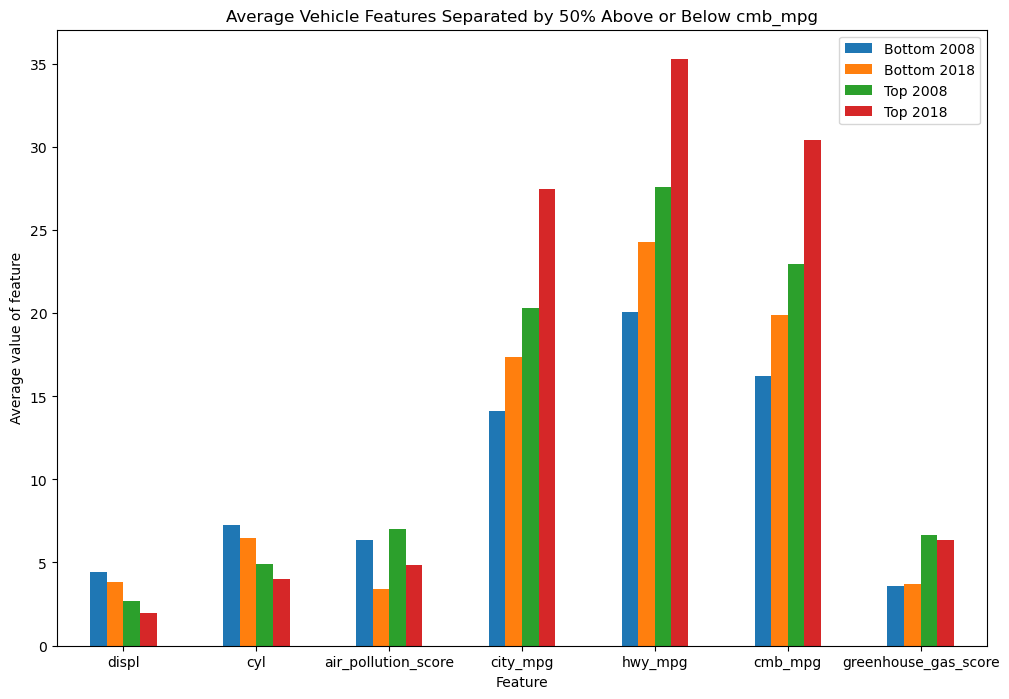

In [35]:
# Plot a bar chart showing top and bottom metrics for 2008 and 2018
# Make sure to use numeric_only=True when geting the mean as we only
# want features that are numbers
pd.DataFrame(
    {
        "Bottom 2008": bottom_08.mean(numeric_only=True),
        "Bottom 2018": bottom_18.mean(numeric_only=True),
        "Top 2008": top_08.mean(numeric_only=True),
        "Top 2018": top_18.mean(numeric_only=True),
    },
    index=top_18.mean(numeric_only=True).index
).plot(
    kind="bar",
    title="Average Vehicle Features Separated by 50% Above or Below cmb_mpg",
    legend=True,
    xlabel="Feature",
    ylabel="Average value of feature",
    rot=0,
    figsize=(12, 8)
);